# DCT Laboratory — Volume I, Chapter 14
## Mathematical Analysis of the Unified Architecture
**Seed `26114`** · Companion to the chapter and AXIOM Module **AXIOM-14**

Analysis instruments on Chapter 13's unified $(K, p)$ system: the **Lipschitz
constant** behind existence and uniqueness, **convergence** to equilibrium,
**perturbation propagation**, and the Sensitivity Theorem's warning made
numerical — steady-state sensitivity **explodes** as coupling nears criticality.
Mirrored in `DCT_V1_Ch14_Lab.xlsx`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110

import numpy as np
SEED = 26114
AKK, AKP, BK = 0.90, 0.20, 4.0
APP, BP = 0.80, 2.0
def A_of(g): return np.array([[AKK, AKP],[g, APP]])
def K_ss(g):
    det = (1-AKK)*(1-APP) - AKP*g
    return ((1-APP)*BK + AKP*BP)/det
def rho(g): return float(max(abs(np.linalg.eigvals(A_of(g)))))
def lip(g):   # spectral norm = sqrt(lambda_max(A^T A))
    return float(np.sqrt(max(np.linalg.eigvals(A_of(g).T @ A_of(g)).real)))

def perturb_norm(k=12, g=0.06, d0=(0.0, 5.0)):
    d = np.array(d0)
    for _ in range(k): d = A_of(g) @ d
    return float(np.linalg.norm(d))

def sens_fd(g, h=0.01):
    return (K_ss(g+h) - K_ss(g))/h

def reference_values():
    return {
        "lip_pre": round(lip(0.06), 4),
        "rho_pre": round(rho(0.06), 4),
        "halve_quarters": round(float(np.log(2)/np.log(1/rho(0.06))), 4),
        "K_ss_006": round(K_ss(0.06), 4), "K_ss_007": round(K_ss(0.07), 4),
        "K_ss_008": round(K_ss(0.08), 4), "K_ss_009": round(K_ss(0.09), 4),
        "sens_fd_low":  round(sens_fd(0.06), 4),
        "sens_fd_high": round(sens_fd(0.08), 4),
        "sens_ratio":   round(sens_fd(0.08)/sens_fd(0.06), 4),
        "pert_norm_12": round(perturb_norm(), 4),
    }
if __name__ == "__main__":
    [print(f"{k:16s} {v}") for k,v in reference_values().items()]

lip_pre          0.9922
rho_pre          0.9704
halve_quarters   23.0814
K_ss_006         150.0
K_ss_007         200.0
K_ss_008         300.0
K_ss_009         600.0
sens_fd_low      5000.0
sens_fd_high     30000.0
sens_ratio       6.0
pert_norm_12     3.0097


## Panel 1 — Existence, uniqueness, convergence
The Existence and Uniqueness Theorems ask for a Lipschitz bound: for the linear
system it is the spectral norm, $L = 0.9922 < 1$ — a contraction, so one solution
exists per start and iterates converge. The rate is $\rho = 0.9704$: the error
halves every **23.08 quarters**. Well-posed and *slow* — both facts matter, and
they are different facts ($L$ vs. $\rho$).

In [2]:
g = 0.06
print(f"Lipschitz (spectral norm) L = {lip(g):.4f}   spectral radius ρ = {rho(g):.4f}")
print(f"error half-life: ln2/ln(1/ρ) = {np.log(2)/np.log(1/rho(g)):.4f} quarters")
z = np.array([40.0, 50.0]); ss = np.array([K_ss(g), 0]);  # track K error only for display
errs = []
x = np.array([40.0, 50.0])
target = None
# iterate far to find the fixed point numerically, then measure error decay
for _ in range(4000): x = A_of(g)@x + np.array([BK, BP])
fp = x.copy()
x = np.array([40.0, 50.0])
for k in range(60):
    errs.append(float(np.linalg.norm(x-fp))); x = A_of(g)@x + np.array([BK, BP])
r = errs[40]/errs[39]
print(f"measured per-step error ratio at k=40: {r:.4f}  (→ ρ)")

Lipschitz (spectral norm) L = 0.9922   spectral radius ρ = 0.9704
error half-life: ln2/ln(1/ρ) = 23.0814 quarters
measured per-step error ratio at k=40: 0.9704  (→ ρ)


## Panel 2 — Sensitivity explodes near criticality
Steady-state capital as a function of the coupling $g$: 150 at 0.06, 200 at
0.07, 300 at 0.08, **600 at 0.09**. The finite-difference sensitivity rises from
5,000 to 30,000 over the same interval — a factor of 6. Sensitivity Depends on
Coupling Strength (Prop.): near criticality, small parameter errors become
large forecast errors, which is the Sensitivity Theorem's operational content.

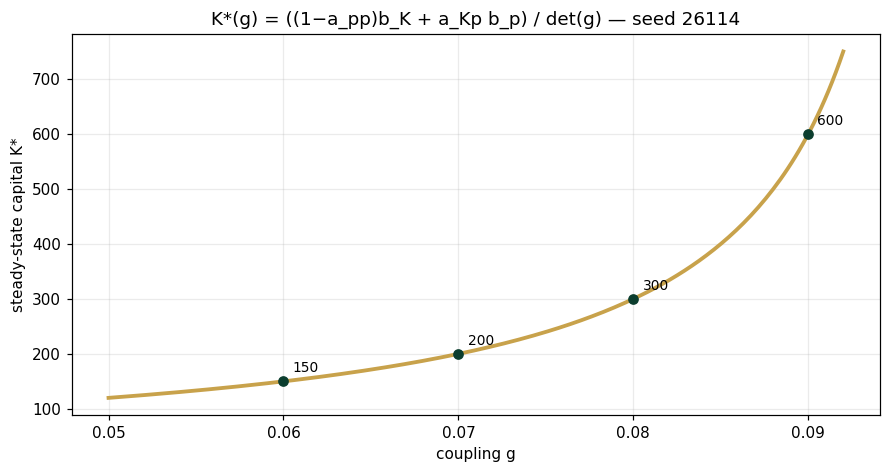

sensitivity (fd, h=0.01): at g=0.06 → 5000.0   at g=0.08 → 30000.0   ratio 6.0


In [3]:
gs = np.linspace(0.05, 0.092, 200)
Ks = [K_ss(g) for g in gs]
fig, ax = plt.subplots(figsize=(8.2,4.4))
ax.plot(gs, Ks, c="#C8A24B", lw=2.5)
for g in (0.06,0.07,0.08,0.09):
    ax.scatter([g],[K_ss(g)], c="#0B3D2E", zorder=5)
    ax.annotate(f"{K_ss(g):.0f}", (g, K_ss(g)), textcoords="offset points", xytext=(6,6), fontsize=9)
ax.set(xlabel="coupling g", ylabel="steady-state capital K*", 
       title="K*(g) = ((1−a_pp)b_K + a_Kp b_p) / det(g) — seed 26114")
ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"sensitivity (fd, h=0.01): at g=0.06 → {sens_fd(0.06):.1f}   at g=0.08 → {sens_fd(0.08):.1f}   ratio {sens_fd(0.08)/sens_fd(0.06):.1f}")

## Panel 3 — Perturbations propagate
A +5 measurement error in performance at $t=0$. The difference system
$\delta_{k+1} = A\delta_k$ carries it through the coupling: after 12 quarters
the error has migrated into capital and decayed to norm **3.01** — Perturbations
Propagate Through Architectural Dependencies (Prop.), traced coordinate by
coordinate.

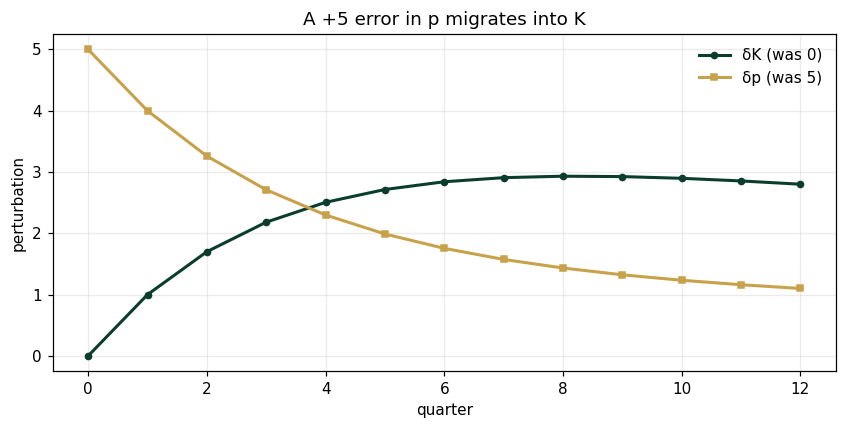

‖δ‖ at k=12: 3.0097


In [4]:
d = np.array([0.0, 5.0]); path = [d.copy()]
for _ in range(12): d = A_of(0.06)@d; path.append(d.copy())
path = np.array(path)
fig, ax = plt.subplots(figsize=(7.8,4.0))
ax.plot(path[:,0], "o-", c="#0B3D2E", lw=2, ms=4, label="δK (was 0)")
ax.plot(path[:,1], "s-", c="#C8A24B", lw=2, ms=4, label="δp (was 5)")
ax.set(xlabel="quarter", ylabel="perturbation", title="A +5 error in p migrates into K")
ax.legend(frameon=False); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"‖δ‖ at k=12: {np.linalg.norm(path[12]):.4f}")

## Validation — agrees with `DCT_V1_Ch14_Lab.xlsx`

In [5]:
ref = reference_values()
expected = {"lip_pre":0.9922,"rho_pre":0.9704,"halve_quarters":23.0814,
 "K_ss_006":150.0,"K_ss_007":200.0,"K_ss_008":300.0,"K_ss_009":600.0,
 "sens_fd_low":5000.0,"sens_fd_high":30000.0,"sens_ratio":6.0,"pert_norm_12":3.0097}
for k,v in expected.items():
    assert abs(ref[k]-v)<5e-4, f"MISMATCH {k}"
    print(f"PASS  {k:16s} {ref[k]}")
print("\nAll checkpoints agree — seed 26114.")

PASS  lip_pre          0.9922
PASS  rho_pre          0.9704
PASS  halve_quarters   23.0814
PASS  K_ss_006         150.0
PASS  K_ss_007         200.0
PASS  K_ss_008         300.0
PASS  K_ss_009         600.0
PASS  sens_fd_low      5000.0
PASS  sens_fd_high     30000.0
PASS  sens_ratio       6.0
PASS  pert_norm_12     3.0097

All checkpoints agree — seed 26114.


**Next**: Exercises 14.9–14.12 (Part C) push g toward det = 0; AXIOM-14's analysis bench plots every instrument against the coupling live. Solutions: IM Ch. 14.